# Límite Clásico del modelo de Ising Cuántico

Número de espins a lo largo de la grilla 1D 8


Array de la grilla:


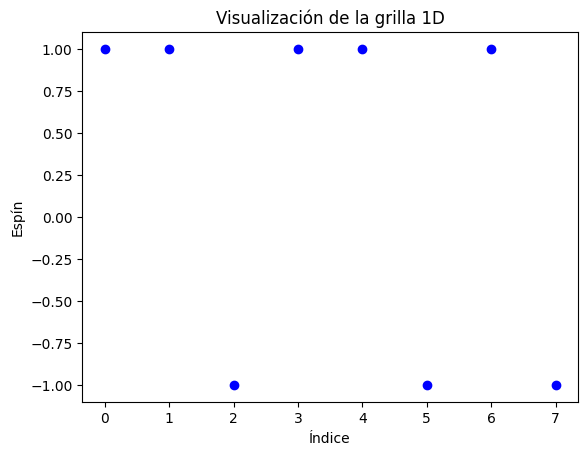

Temperatura deseada (K) para el entorno de la grilla: 0.125


Inválido, por favor escribir un entero.


Temperatura deseada (K) para el entorno de la grilla: 1
Número de iteraciones para Metropolis-Hastings: 10000


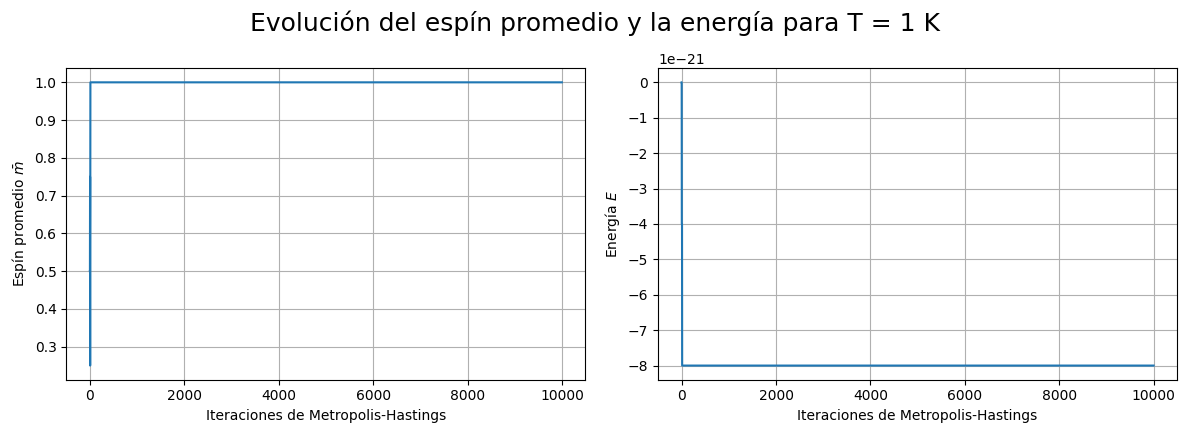

****************************************************************************************************
Ahora, se calcula para observar el comportamiento del algoritmo respecto a múltiples variables termodinámicas en un rango de temperaturas.


Temperatura mínima (K): 1
Temperatura máxima (K): 10000


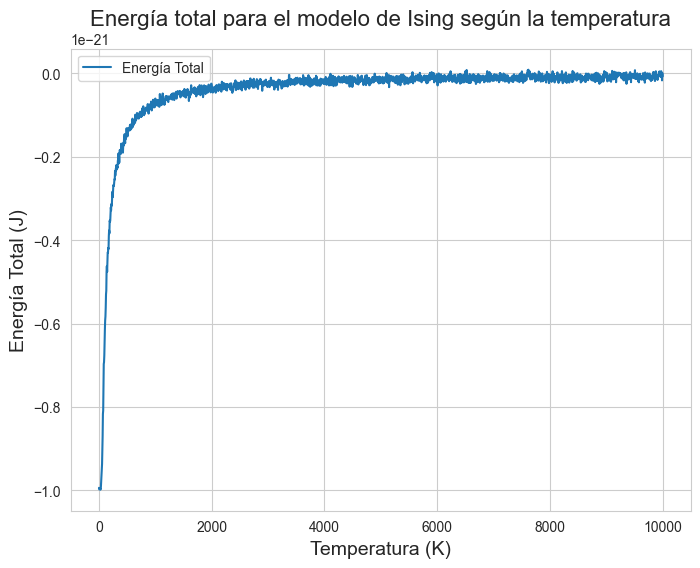

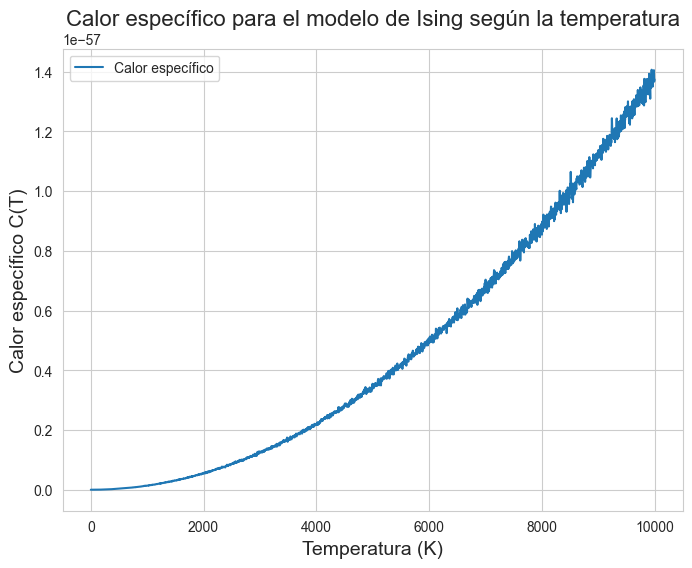

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import scipy.constants as sc
from scipy.ndimage import convolve
from scipy.ndimage import generate_binary_structure




'''
---------------------------------------------------------------
    
    Funciones
   
---------------------------------------------------------------
'''

def visualizar_1d_lattice(lattice):
    plt.plot(lattice, marker='o', linestyle='None', color='blue')
    plt.title("Visualización de la grilla 1D")
    plt.xlabel("Índice")
    plt.ylabel("Espín")

    # Establece los ticks según el tamaño del lattice
    x_ticks = np.arange(len(lattice))
    plt.xticks(x_ticks, labels=x_ticks)
    plt.show()
    

def generar_lattice():
    """
    Genera un lattice de espíns al azar entre -1 y +1, utilizando la probabilidad uniforme. Queda pendiente corroborar que una probabilidad 50-50% sea apropiada a nivel físico, puesto que el espín promedio debe ser 0
    """
    lattice = None

    while True:
        try:
            size = int(input("Número de espins a lo largo de la grilla 1D"))
            break
        except ValueError:
            print("Valor equivocado, utilice un integer")
    lattice = np.random.choice([-1, +1], size=size) #En caso que la probabilidad sea diferente, agregar el último parámetro

    return lattice



def lattice_energia(system, J):
    ''' 
    Realiza una sumatoria sobre cada espín del lattice con tal de encontrar su energía. Se utiliza el system, que es el array de espines con condiciones de frontera, la energía de intercambio J y sin campo magnético externo

    '''
    
    # En este caso, que es el unidimensional, los vecinos más cercanos son simplemente los espíns adyacentes
    s_i_plus1 = np.roll(system,-1) #Desplaza cada s_i hacia la izquierda, se utiliza debido a la frontera periódica
    total_energy = -J*np.sum(system*s_i_plus1)
    return total_energy

 
def metropolis_1D_periodica(spin_array,times, T, J):
    '''
    Función que toma el array unidimensional de espínes con condiciones periódicas, el número de iteraciones times, la temperatura T, la energía de intercambio J y sin campo magnético externo,
    y consecuentemente realiza MCMC para producir el array de espínes netos y energías

    '''
    energy = lattice_energia(spin_array,J)
    k = sc.Boltzmann
    B = 1/(k*T) # Beta en terminos de temperatura
    spin_array = spin_array.copy()
    net_spins = np.zeros(times-1)
    net_energy = np.zeros(times-1)
    for t in range(0,times-1):
        # 2. Se escoge un punto aleatorio en el array y un volteo del espin
        n_x = len(spin_array)
        x = np.random.randint(0,n_x)
        spin_i = spin_array[x] #Espin inicial
        spin_f = spin_i*-1 #Volteo del espín propuesto, dado que solo alterna entre -1 y +1
        
        # Cambio de la energía dada las condiciones de frontera periódicas
        E_i = 0
        E_f = 0
        # Vecino izquierdo
        if x==0:
            E_i += -spin_i*spin_array[n_x-1]
            E_f += -spin_f*spin_array[n_x-1]
        if x>0:
            E_i += -spin_i*spin_array[x-1]
            E_f += -spin_f*spin_array[x-1]
        # Vecino derecho
        if x<n_x-1:
            E_i += -spin_i*spin_array[x+1]
            E_f += -spin_f*spin_array[x+1]
        if x == n_x-1:
            E_i += -spin_i*spin_array[0]
            E_f += -spin_f*spin_array[0]
        
        # 3 / 4. Cambio de estado para probabilidades designadas
        E_i = J*E_i
        E_f = J*E_f
        
        dE = E_f-E_i
        P = np.random.random(1)[0] # Generación de un número aleatorio
        if (dE>0)*(P < np.exp(-B*dE)):
            spin_array[x]=spin_f
            energy += dE
        elif dE<=0:
            spin_array[x]=spin_f
            energy += dE
            
        net_spins[t] = spin_array.sum()
        net_energy[t] = energy
            
    return net_spins, net_energy, spin_array



    
def thermo_calc_1D(min_temp, max_temp, system, times, J):
    ''' 
    Obtiene el los totales y las desviaciones asociadas a las energías y espines en el rango de temperaturas mediante MCMC y calcula las cantidades asociadas.
    Se trabaja con los límites de temperatura, el array system que representa el lattices de espines, la energía de intercambio J y sin campo magnético h
    '''
    k = sc.Boltzmann
    # Generación de un array para el rango de temperaturas especificado
    temps = np.arange(min_temp, max_temp,5)
    n = len(temps)
    #Arrays vacíos para los totales y las varianzas
    E_totals = np.zeros(n)
    E_vars = np.zeros(n)
    C = np.zeros(n)
    N = len(system)
    
    # Se itera sobre todas las temperaturas en el rango, usando Metropolis-Hastings para encontrar los espins y las energías
    for i in range(n):
        spins, energies, lattice_final = metropolis_1D_periodica(system,times,temps[i],J) # MCMC para las diferentes temperatura
        
        E_totals[i] += np.mean(energies[-10000:])/(N) # Energía total en cada temperatura
        E_vars[i] += np.var(energies[-10000:]) # Varianza de la energía para cada temperatura
        C[i] = E_vars[i]/(N)*k*(temps[i]**2) # Calor específico para la varianza de energía

        
    return E_totals, C






"""

---------------------------------------------------------------

Main

----------------------------------------------------------------

"""


#Generación del lattice
lattice = generar_lattice()
print("Array de la grilla:")
visualizar_1d_lattice(lattice)
n_x = lattice.shape[0]  #Se asigna el tamaño del lattice según la primera dimensión de n_x. En este caso solo existe n_x, pero con tal de no perder generalidad se le refiere así en lugar de solo como n
V = n_x





#Inicialización del sistema
J = (1 * (10**-21)) # Se escoge una magnitud baja (correspondiento a la de la constante de boltzmann) con tal de evitar overflowing por la magnitud de las energías.
#También, J se escoge positivo puesto que se escoge estudiar un material ferromagnético


while True:
    T = input("Temperatura deseada (K) para el entorno de la grilla:")
    try: 
        T = int(T)
        break
    except:
        print ("Inválido, por favor escribir un entero.")

while True:
    iterations = input("Número de iteraciones para Metropolis-Hastings:")
    try: 
        iterations = int(iterations)
        break
    except:
        print ("Inválido, por favor escribir un entero.")
        
        
        
init_energy = lattice_energia(lattice,J)


#Se aplica MCMC para obtener las cantidades

spins, energies, lattice_final =  metropolis_1D_periodica(lattice,iterations,T,J)  

 
#Graficación

fig,axes = plt.subplots(1,2,figsize=(12,4))
# Plot de espines
ax = axes[0]
ax.plot(spins/V)
ax.set_xlabel("Iteraciones de Metropolis-Hastings")
ax.set_ylabel(r'Espín promedio $\bar{m}$')
ax.grid()
# Plot for Energies
ax = axes[1]
ax.plot(energies)
ax.set_xlabel("Iteraciones de Metropolis-Hastings")
ax.set_ylabel(r'Energía $E$')
ax.grid()
fig.tight_layout()
fig.suptitle(r'Evolución del espín promedio y la energía para T = {} K'.format(T),y = 1.07, size=18)
plt.show()

#Obtención del rango de temperatura y los datos termodinámicos

print("*"*10**2)
print('Ahora, se calcula para observar el comportamiento del algoritmo respecto a múltiples variables termodinámicas en un rango de temperaturas.')
#Se trabajan con integers solo por facilidad
while True:
    T_min = input("Temperatura mínima (K):")
    try: 
        T_min = int(T_min)
        break
    except:
        print ("Inválido, por favor escribir un entero.")
while True:
    T_max = input("Temperatura máxima (K):")
    try: 
        T_max = int(T_max)
        break
    except:
        print ("Inválido, por favor escribir un entero.")
        
temp_range = np.arange(T_min,T_max,5)        

E_totals, C = thermo_calc_1D(T_min, T_max, lattice, iterations, J)


#Graficación de la energía total según la temperatura


# Se usa seaborn
sns.set_style("whitegrid")

f1 = plt.figure(figsize=(8, 6)) 
plt.plot(temp_range, E_totals, label="Energía Total")
plt.title("Energía total para el modelo de Ising según la temperatura", fontsize=16)
plt.xlabel("Temperatura (K)", fontsize=14)
plt.ylabel("Energía Total (J)", fontsize=14)
plt.legend()

plt.show()


#Capacidad calorífica según la temperatura

sns.set_style("whitegrid")

f2 = plt.figure(figsize=(8, 6)) 
plt.plot(temp_range, C, label="Calor específico")
plt.title("Calor específico para el modelo de Ising según la temperatura", fontsize=16)
plt.xlabel("Temperatura (K)", fontsize=14)
plt.ylabel("Calor específico C(T)", fontsize=14)
plt.legend()

plt.show()




# Ising transversal

Modelo de Ising Transversal
Simulación de Monte Carlo
Barrido de h: 0.1 -> 2.0)
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 0.1


Punto 1/20: h = 0.10 -> |mz| = 0.9985
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 0.2


Punto 2/20: h = 0.20 -> |mz| = 0.9959
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 0.3


Punto 3/20: h = 0.30 -> |mz| = 0.9877
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 0.4


Punto 4/20: h = 0.40 -> |mz| = 0.9778
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 0.5


...

Punto 16/20: h = 1.60 -> |mz| = 0.2363
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 1.7


Punto 17/20: h = 1.70 -> |mz| = 0.2641
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 1.8


Punto 18/20: h = 1.80 -> |mz| = 0.2213
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 1.9


Punto 19/20: h = 1.90 -> |mz| = 0.1499
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parámetros: J = 1.0, h = 2.0


Punto 20/20: h = 2.00 -> |mz| = 0.1875


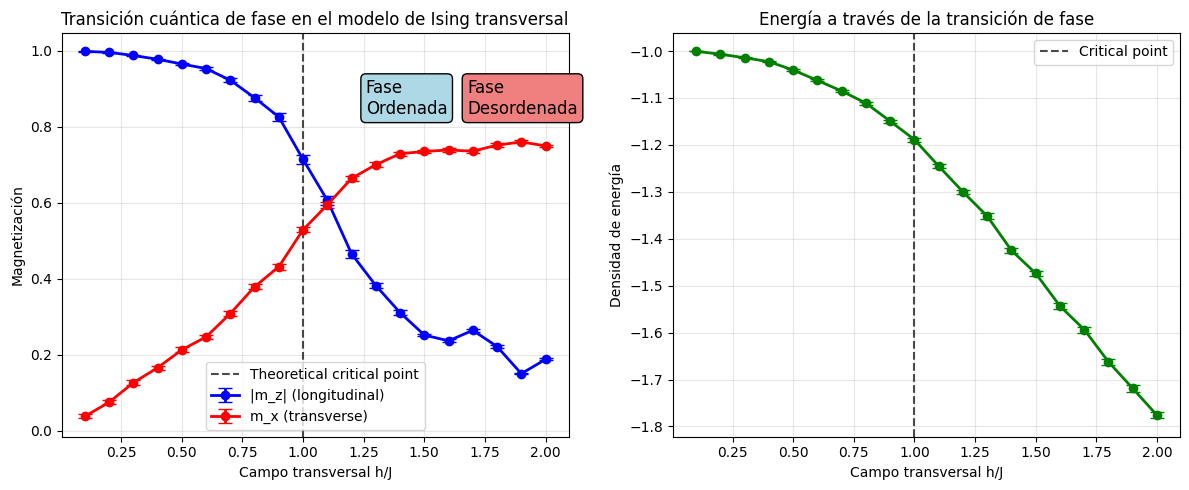


Comparación con resultados analíticos (Diagonalización Exacta)
h/J = 0.5: |m_z| = 0.9693, m_x = 0.2601, E_density = -1.0636
h/J = 1.0: |m_z| = 0.7858, m_x = 0.6407, E_density = -1.2815
h/J = 1.5: |m_z| = 0.5615, m_x = 0.8723, E_density = -1.6731


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

class TransverseIsingPIMC:
    """
    
    Path Integral Monte Carlo (PIMC) para el modelo de Ising con un campo externo transversal. 
    Puesto que el proceso es más complejo que el anterior, del modelo clásico, es más conveniente generar una clase con las variables y funciones del proceso.
    """
    
    def __init__(self, N, J=1.0, h=1.0, beta=1.0, M=20):
        """
        Se inicializa la simulación de PIMC
        """
        self.N = N
        self.J = J
        self.h = h
        self.beta = beta
        self.M = M
        
        # Discretización del tiempo imaginario
        self.dtau = beta / M
        
        # Inicialización de la configuración del espín, con N posiciones espaciales x M "slices" temporales
        self.config = np.random.choice([-1, 1], size=(N, M))
        
        # Se computa de previo la constante de acoplamiento para la dirección en el tiempo imaginario
        self.K = -0.5 * np.log(np.tanh(self.dtau * self.h))
        #IMPORTANTE, como la constante temporal depende del campo, evaluar el caso aproximadamente sin campo externo va a causar que este valor tienda a infinito debido al logaritmo
        
    def magnetization_z_sq(self, config):
        """
        Cálculo de la densidad de magnetización longitudinal. Se calcula la media cuadrada, luego se realizará la raíz cuadrada, fuera de esta función
        """
        m_z = np.mean(config)
        return m_z ** 2 # Return the square of the instantaneous average
    
    def magnetization_x(self, config):
        """
        Una forma conveniente de realizar este cálculo es contando los "kinks", o 
        los volteos en el tiempo imaginario.
        """
        # 1. Se identifican donde los espins ocurren entre t y t+1
        # Si la configuración es igual a la configuración después del np.roll, el producto es 1.
        #De lo opuesto, es -1

        time_correlations = config * np.roll(config, -1, axis=1) 
        
        # -1 implica la presencia de un kink; 1, la ausencia de un kink
        #Entonces, se cuentan cuantas celdas tienen kinks
        num_kinks = np.sum(time_correlations == -1)
        
        # Fórmula del estimador para la densidad de kinks, la cual da mx
        mx = num_kinks / (self.N * self.beta * self.h)
        
        return mx

    def energy_density(self, config):
        """
        Calcula la energía de interacción y la del campo transversal
        E_total = <H_z> + <H_x>
        """
        # H_z: Interaction Energy
        # E_z = -J * <sum(S_i * S_i+1)> , igual a como se realizó previamente en el cálculo clásico
        spatial_correlations = config * np.roll(config, -1, axis=0)
        E_z = -self.J * np.mean(spatial_correlations)
        
        # H_x: Transverse Field Energy
        # E_x = -h * <m_x>
        # Se realiza el mismo cálculo en la función de magnetization, pero se calcula de manera local para que sea contenido dentro de este cálculo en específico
        time_correlations = config * np.roll(config, -1, axis=1) 
        num_kinks = np.sum(time_correlations == -1)
        m_x_val = num_kinks / (self.N * self.beta * self.h)
        
        E_x = -self.h * m_x_val
        
        return E_z + E_x
        
    
    

    def local_update(self, config, i, t):
        """
        Se realiza una actualización de Metrópolis para un spin en la posición(i, t)
        Este proceso podría ser realizado con el muestreo de Gibbs, pero se requeriría la probabilidad
        condicional, lo cuál necesitaría la implementación de métodos alternos como el uso de RBM's
        """
        current_spin = config[i, t]
        
        # Cálculo del cambio de energía para el criterio de aceptación
        delta_E = 0.0
        
        # Vecinos espaciales dentro del mismo slice temporal
        left = config[(i-1) % self.N, t]
        right = config[(i+1) % self.N, t]
        
        # Ahora, para la parte espacial es necesario multipliar por dTau
        delta_E += 2 * (self.dtau * self.J) * current_spin * (left + right)
        
        # Vecinos temporales, análogo al anterior caso, pero fijando el sitio y variando el tiempo
        t_prev = (t - 1) % self.M
        t_next = (t + 1) % self.M
        #El delta E integra también el término asociado a este tiempo imaginario, y aquí se utiliza la constante de acoplamiento temporal
        delta_E += 2 * self.K * current_spin * (config[i, t_prev] + config[i, t_next]) 
        
        # El criterio de aceptación de toda la vida
        if delta_E <= 0 or np.random.random() < np.exp(-delta_E):
            config[i, t] = -current_spin
            return True
        return False
        
    def wolff_update(self, config):
        """
        Algoritmo de cúmulo (Wolff) para cálculos más eficientes.
        Cluster update (Wolff algorithm) for more efficient sampling
        """
        # Se escoge un "seed" o semilla aleatoria para el spin
        i0, t0 = np.random.randint(0, self.N), np.random.randint(0, self.M)
        cluster = [(i0, t0)]
        stack = [(i0, t0)]
        old_spin = config[i0, t0]
        
        # Se construye el cúmulo
        while stack:
            i, t = stack.pop()
            
            # Se chequea por los vecinos espaciales
            for di in [-1, 1]:
                i_nbr = (i + di) % self.N
                if (i_nbr, t) not in cluster:
                    # Probabilidad original: 1 - exp(-2 * J * dtau). 
                    # Este es el acoplamiento clásico para el término espacial
                    # El acoplamiento espacial para el caso clásico es entonces J_cl = dtau*J.
                    # Se usa la probabilidad explícita para el caso clásico K, K_tau:
                    P_add = (1 - np.exp(-2 * self.dtau * self.J)) # P_add para el espacial
                    if (config[i_nbr, t] == old_spin and 
                        np.random.random() < P_add):
                        cluster.append((i_nbr, t))
                        stack.append((i_nbr, t))
                        
            # Ahora se repite el procedimiento para los vecinos temporales
            for dt in [-1, 1]:
                t_nbr = (t + dt) % self.M
                if (i, t_nbr) not in cluster:
                    # Probabilidad original: 1 - exp(-2 * K)
                    P_add_tau = (1 - np.exp(-2 * self.K)) # P_add para el término temporal
                    if (config[i, t_nbr] == old_spin and 
                        np.random.random() < P_add_tau):
                        cluster.append((i, t_nbr))
                        stack.append((i, t_nbr))
        
        # Se realiza un flip sobre todo el cúmulo
        for i, t in cluster:
            config[i, t] = -config[i, t]
        
        return len(cluster)
        
    def run(self, n_sweeps, thermalization=0.2, measure_every=10):
        """
        Simulación completa de Monte Carlo
        """
        print(f"PIMC: {self.N} spins, {self.M} Trotter slices, β = {self.beta}")
        print(f"Parámetros: J = {self.J}, h = {self.h}")
        n_therm = int(n_sweeps * thermalization)
        
        
        # Arrays para guardar las mediciones
        energies = []
        mag_z_sq_values = [] 
        mag_x_values = []

        #Se usa una barra de progreso
        iterator = tqdm(range(n_sweeps), desc=f"Simulando h={self.h:.2f}", leave=False, ncols=80)
        

        
        for sweep in iterator:
            # Se realiza una actualización mezclada, local + cúmulo (este último ocasionalmente, no todas las veces)
            if sweep % 10 == 0:  # Se actualiza en cúmulo cada 10 sweeps
                self.wolff_update(self.config)
            else:  # actualizaciones locales
                for _ in range(self.N * self.M):
                    i = np.random.randint(0, self.N)
                    t = np.random.randint(0, self.M)
                    self.local_update(self.config, i, t)
            
            # Medida de observables después de la termalización
            if sweep >= n_therm and sweep % measure_every == 0:
                energy = self.energy_density(self.config)
                mag_z_sq = self.magnetization_z_sq(self.config)
                mag_x = self.magnetization_x(self.config)
                
                energies.append(energy)
                mag_z_sq_values.append(mag_z_sq)
                mag_x_values.append(mag_x)
        
        # Valores promedios y errores
        
        # Como se mencionó en la función de magnetización ,ahora se toma la raíz con tal de obtener |mz|
        mean_mz_sq = np.mean(mag_z_sq_values)
        final_mz = np.sqrt(mean_mz_sq)
        
        # La desviación de mz se usa para cuantificar la propagación del error
        mz_sq_std = np.std(mag_z_sq_values) / np.sqrt(len(mag_z_sq_values))
        # Este es meramente un aproximado, pero para términos ilustrativos logra visibilizar como funciona el error según los parámetros

        results = {
            'energy': np.mean(energies),
            'energy_std': np.std(energies) / np.sqrt(len(energies)),
            'magnetization_z': final_mz, 
            'magnetization_z_std': mz_sq_std,
            'magnetization_x': np.mean(mag_x_values),
            'magnetization_x_std': np.std(mag_x_values) / np.sqrt(len(mag_x_values)),
        }
        
        return results

def quick_critical_check(n_points=20, h_min=0.1, h_max=2.0):
    """
    Verificación usando un linspace para barrer el campo h.
    Genera n_points entre h_min y h_max y obtiene los cálculos con los que luego se verificará
    """
    
    print(f"Barrido de h: {h_min} -> {h_max})")
    print("=" * 60)
    
    h_values = np.linspace(h_min, h_max, n_points)
    
    all_results = []
    
    # Parámetros fijos para la prueba, se quiere ver el cambio con respecto a h
    base_params = {'N': 8, 'J': 1.0, 'beta': 8.0, 'M': 80}
    
    for i, h in enumerate(h_values):
        # Se actualiza h
        params = base_params.copy()
        params['h'] = h
        
        # Se corre el modelo con los parámetros
        model = TransverseIsingPIMC(**params)
        results = model.run(n_sweeps=2500, thermalization=0.2, measure_every=5)
        
        # Se guardan los resultados
        results['h'] = h
        
        # Etiqueta dinámica, con tal de observar el comportamiento en los rangos de mayor interes
        if h < 0.9:
            results['label'] = 'Ordenado'
        elif h > 1.1:
            results['label'] = 'Desordenado'
        else:
            results['label'] = 'Crítico'
            
        all_results.append(results)
        
        # Barra de progreso simple en texto
        print(f"Punto {i+1}/{n_points}: h = {h:.2f} -> |mz| = {results['magnetization_z']:.4f}")
    
    return all_results

def plot_quick_results(results):
    """Plot the quick verification results"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Extracción de datos
    h_vals = [r['h'] for r in results]
    mz_vals = [r['magnetization_z'] for r in results]
    mz_err = [r['magnetization_z_std'] for r in results]
    mx_vals = [r['magnetization_x'] for r in results]
    mx_err = [r['magnetization_x_std'] for r in results]
    
    # Graficación de magnetización
    ax1.errorbar(h_vals, mz_vals, yerr=mz_err, fmt='bo-', label='|m_z| (longitudinal)', capsize=5, linewidth=2)
    ax1.errorbar(h_vals, mx_vals, yerr=mx_err, fmt='ro-', label='m_x (transverse)', capsize=5, linewidth=2)
    ax1.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, label='Theoretical critical point')
    ax1.set_xlabel('Campo transversal h/J')
    ax1.set_ylabel('Magnetización')
    ax1.set_title('Transición cuántica de fase en el modelo de Ising transversal')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Etiquetas de fase
    ax1.text(0.6, 0.8, 'Fase\nOrdenada', transform=ax1.transAxes, fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    ax1.text(0.8, 0.8, 'Fase\nDesordenada', transform=ax1.transAxes, fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
    
    # Graficación de energía
    energy_vals = [r['energy'] for r in results]
    energy_err = [r['energy_std'] for r in results]
    
    ax2.errorbar(h_vals, energy_vals, yerr=energy_err, fmt='go-', capsize=5, linewidth=2)
    ax2.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, label='Critical point')
    ax2.set_xlabel('Campo transversal h/J')
    ax2.set_ylabel('Densidad de energía')
    ax2.set_title('Energía a través de la transición de fase')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

def analytical_benchmark():
    """Se compara con los resultados diagnolización exacta Compare with exact diagonalization for small system"""
    print("\n" + "=" * 60)
    print("Comparación con resultados analíticos (Diagonalización Exacta)")
    print("=" * 60)
    
    def get_pauli(n, size, pauli_type):
        if pauli_type not in ['x', 'y', 'z']:
            raise ValueError("pauli_type must be 'x', 'y', or 'z'")
        pauli_matrices = {
            'x': np.array([[0, 1], [1, 0]], dtype=complex),
            'y': np.array([[0, -1j], [1j, 0]], dtype=complex),
            'z': np.array([[1, 0], [0, -1]], dtype=complex)
        }
        op = pauli_matrices[pauli_type]
        full_op = 1
        for i in range(size):
            if i == n:
                full_op = np.kron(full_op, op)
            else:
                full_op = np.kron(full_op, np.eye(2))
        return full_op

    def build_tfim_hamiltonian(N, J=1.0, h=1.0):
        H = sp.csr_matrix((2**N, 2**N), dtype=complex)
        # Término de interacción
        for i in range(N):
            j = (i + 1) % N
            sz_i = get_pauli(i, N, 'z')
            sz_j = get_pauli(j, N, 'z')
            H -= J * (sz_i @ sz_j)
        # Transverse field term
        for i in range(N):
            sx_i = get_pauli(i, N, 'x')
            H -= h * sx_i
        return H.real

    N = 8  # Se escoge un sistema pequeño a conveniencia
    test_h = [0.5, 1.0, 1.5] #Estos son 3 valores en los tres puntos de interés: regímen ordenado, régimen crítico y régimen desordenado
    
    for h in test_h:
        H = build_tfim_hamiltonian(N, J=1.0, h=h)
        eigenvalues, eigenvectors = eigsh(H, k=1, which='SA')
        ground_state = eigenvectors[:, 0]
        
        # 1. Cálculo del operador Mz (la suma de sigma_z)
        Mz_op = sp.csr_matrix((2**N, 2**N), dtype=complex)
        Mx_op = sp.csr_matrix((2**N, 2**N), dtype=complex)
        
        for i in range(N):
            Mz_op += get_pauli(i, N, 'z')
            Mx_op += get_pauli(i, N, 'x')
            
        # 2. Cálculo del valor de expectación de Mz^2, la magnetización cuadrada
        mz_sq_exp = (ground_state.conj().T @ (Mz_op @ Mz_op) @ ground_state).real.item()
        # @ es el operador de multiplicación de matrices
        
        # 3. Cálculo de la magnetización RMS por sitio:
        m_z = np.sqrt(mz_sq_exp) / N
        
        # 4. Cálculo de la magnetización transversal por sitio
        m_x = (ground_state.conj().T @ Mx_op @ ground_state).real.item() / N
        
        # 5. Cálculo de la densidad de energía
        e_density = eigenvalues[0].real / N
        
        print(f"h/J = {h:.1f}: |m_z| = {m_z:.4f}, m_x = {m_x:.4f}, E_density = {e_density:.4f}")

if __name__ == "__main__":
    print("Modelo de Ising Transversal")
    print("Simulación de Monte Carlo")
    print("=" * 60)
    
    results = quick_critical_check()
    
    plot_quick_results(results)
    
    analytical_benchmark()


# Ising Disipativo

Notar como, en el caso sin disipación, se llega a los mismos resultados vistos para la aproximación del modelo de Ising transversal regular

## Graficación de la magnetización respecto a la disipación

 GENERACIÓN DE DIAGRAMA DE FASES DISIPATIVO
Parámetros fijos: N=8, h=1.5, beta=10.0
Escaneando Alpha: [0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6, 2.0]
------------------------------------------------------------


Barrido de α:  10%|███                           | 1/10 [00:19<02:56, 19.62s/it]

α = 0.00: |m_z| = 0.2672, m_x = 0.6640 (19.6s)


Barrido de α:  20%|██████                        | 2/10 [00:44<03:03, 22.97s/it]

α = 0.02: |m_z| = 0.3641, m_x = 0.5890 (25.3s)


...

α = 1.20: |m_z| = 1.0000, m_x = 0.0001 (28.8s)


Barrido de α:  90%|███████████████████████████   | 9/10 [03:53<00:27, 27.12s/it]

α = 1.60: |m_z| = 1.0000, m_x = 0.0000 (28.0s)


Barrido de α: 100%|█████████████████████████████| 10/10 [04:24<00:00, 26.44s/it]

α = 2.00: |m_z| = 1.0000, m_x = 0.0000 (31.1s)
------------------------------------------------------------
Tiempo total: 264.4s


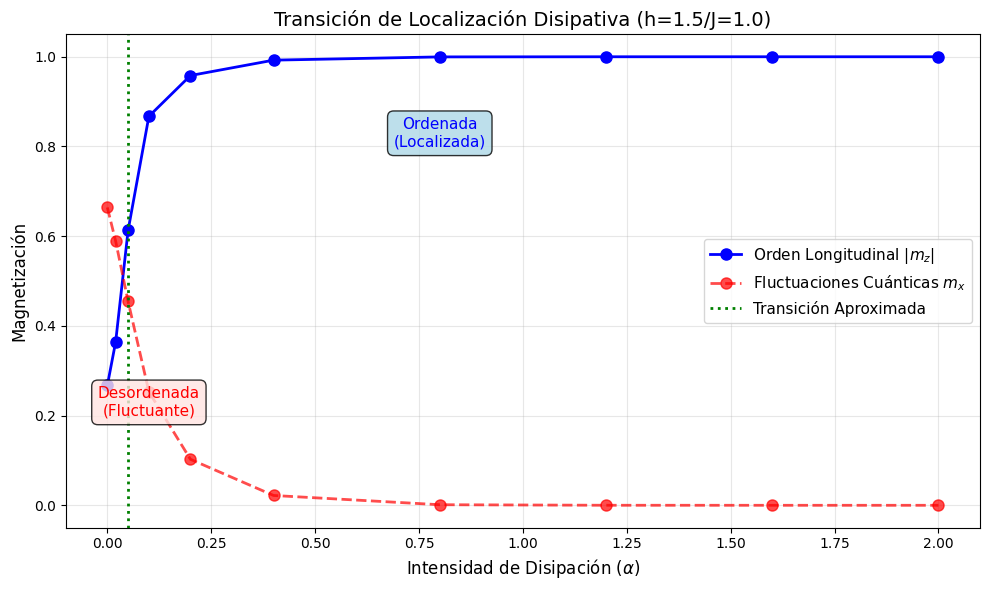


INTERPRETACIÓN:
------------------------------------------------------------
• α = 0: Fase desordenada cuántica (bajo |m_z|, alto m_x)
• α ≈ 0.05: Punto crítico de la transición
• α > 0.2: Fase localizada (alto |m_z|, bajo m_x)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

class DissipativePIMC:
    """
    Path Integral Monte Carlo (PIMC) para el modelo de Ising con campo transversal disipativo.
    Se incluyen actualizaciones globales para prevenir el congelamiento a alta disipación.
    """
    
    def __init__(self, N, J=1.0, h=1.0, beta=1.0, M=60, alpha=0.0):
        """
        Inicialización de la simulación PIMC con disipación.
        
        M se establece en 60 por defecto para mayor velocidad de graficación.
        Incrementar a 80 o 100 para datos de calidad de publicación.
        """
        self.N = N
        self.J = J
        self.h = h
        self.beta = beta
        self.M = M
        self.alpha = alpha
        
        # Discretización del tiempo imaginario
        self.dtau = beta / M
        
        # Inicialización de la configuración del espín
        self.config = np.random.choice([-1, 1], size=(N, M))
        
        # Constante de acoplamiento temporal
        self.K = -0.5 * np.log(np.tanh(self.dtau * self.h))
        
        # Matriz del kernel disipativo
        self.kernel_matrix = np.zeros((M, M))
        if self.alpha > 0:
            self._precompute_kernel()
            
    def _precompute_kernel(self):
        """
        Pre-cálculo del kernel disipativo.
        La disipación introduce interacciones no locales en el tiempo imaginario.
        """
        for t in range(self.M):
            for t_prime in range(self.M):
                if t == t_prime: 
                    continue
                
                # Distancia entre slices temporales
                dist_slices = abs(t - t_prime)
                
                # Métrica de distancia de cuerda
                chord_dist_sq = (self.M / np.pi * np.sin(np.pi * dist_slices / self.M))**2
                
                # Acoplamiento disipativo
                coupling = self.alpha * (np.pi**2) / (self.M**2) / (np.sin(np.pi * dist_slices / self.M)**2)
                
                self.kernel_matrix[t, t_prime] = coupling

    def measure_observables(self):
        """
        Medición de observables del sistema:
        1. Magnetización longitudinal |m_z|
        2. Magnetización transversal m_x (conteo de kinks)
        """
        # 1. Magnetización longitudinal
        m_z = np.mean(self.config)
        m_z_sq = m_z**2
        
        # 2. Magnetización transversal (contando kinks)
        time_correlations = self.config * np.roll(self.config, -1, axis=1)
        num_kinks = np.sum(time_correlations == -1)
        m_x = num_kinks / (self.N * self.beta * self.h)
        
        return m_z_sq, m_x

    def local_update(self, i, t):
        """
        Actualización local estándar de un solo sitio (i, t).
        Incluye los términos espacial, temporal y disipativo.
        """
        current_spin = self.config[i, t]
        
        # Término espacial: vecinos en la misma slice temporal
        left = self.config[(i-1) % self.N, t]
        right = self.config[(i+1) % self.N, t]
        delta_E_spatial = 2 * (self.dtau * self.J) * current_spin * (left + right)
        
        # Término temporal: vecinos en slices adyacentes
        t_prev = (t - 1) % self.M
        t_next = (t + 1) % self.M
        delta_E_temporal = 2 * self.K * current_spin * (self.config[i, t_prev] + self.config[i, t_next])
        
        # Término disipativo: interacción no local en el tiempo imaginario
        delta_E_diss = 0.0
        if self.alpha > 0:
            interaction_sum = np.dot(self.kernel_matrix[t, :], self.config[i, :])
            delta_E_diss = 2 * current_spin * interaction_sum

        # Cambio total de energía
        delta_E = delta_E_spatial + delta_E_temporal + delta_E_diss
        
        # Criterio de aceptación de Metrópolis
        if delta_E <= 0 or np.random.random() < np.exp(-delta_E):
            self.config[i, t] = -current_spin

    def uniform_update(self, i):
        """
        ACTUALIZACIÓN GLOBAL: voltea toda la varilla temporal en el sitio espacial i.
        Crucial para alpha alto, previene el congelamiento del sistema.
        """
        current_rod = self.config[i, :]
        left_rod = self.config[(i-1) % self.N, :]
        right_rod = self.config[(i+1) % self.N, :]
        
        # Cálculo del cambio de energía espacial para toda la varilla
        spatial_neighbors = left_rod + right_rod
        delta_E_total = 2 * (self.dtau * self.J) * np.sum(current_rod * spatial_neighbors)
        
        # Criterio de aceptación para toda la varilla
        if delta_E_total <= 0 or np.random.random() < np.exp(-delta_E_total):
            self.config[i, :] *= -1 

    def run(self, n_sweeps, thermalization=0.3):
        """
        Simulación completa de Monte Carlo con disipación.
        Combina actualizaciones locales con actualizaciones globales.
        """
        n_therm = int(n_sweeps * thermalization)
        
        # Arrays para guardar las mediciones
        mz_sq_list = []
        mx_list = []
        
        for sweep in range(n_sweeps):
            # 1. Actualizaciones locales
            for _ in range(self.N * self.M):
                i = np.random.randint(0, self.N)
                t = np.random.randint(0, self.M)
                self.local_update(i, t)
            
            # 2. Actualizaciones uniformes
            for i in range(self.N):
                self.uniform_update(i)
            
            # Mediciones después de la termalización
            if sweep >= n_therm and sweep % 10 == 0:
                mz_sq, mx = self.measure_observables()
                mz_sq_list.append(mz_sq)
                mx_list.append(mx)
        
        # Cálculo de promedios
        final_mz = np.sqrt(np.mean(mz_sq_list))
        final_mx = np.mean(mx_list)
        
        return {'m_z': final_mz, 'm_x': final_mx}

# ==========================================
# SCRIPT DE GRAFICACIÓN DE TRANSICIÓN DE FASE
# ==========================================
if __name__ == "__main__":
    print("=" * 60)
    print(" GENERACIÓN DE DIAGRAMA DE FASES DISIPATIVO")
    print("=" * 60)
    
    # 1. Definición de parámetros
    # Se escoge h=1.5 porque está en la fase desordenada (m_z bajo) cuando alpha=0.
    # Se quiere observar cómo se vuelve ordenada (m_z alto) a medida que alpha aumenta.
    N = 8
    J = 1.0
    h = 1.5 
    beta = 10.0
    M = 60  # Slices temporales
    sweeps = 3000  # Sweeps por punto
    
    # Rango de valores de Alpha a escanear
    # Se concentran alrededor de 0.05 donde la transición probablemente ocurre
    alpha_values = [0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6, 2.0]
    
    mz_results = []
    mx_results = []
    
    print(f"Parámetros fijos: N={N}, h={h}, beta={beta}")
    print(f"Escaneando Alpha: {alpha_values}")
    print("-" * 60)
    
    start_total = time.time()
    
    # 2. Ejecución del bucle
    # Se usa tqdm para mostrar el progreso del barrido
    for alpha in tqdm(alpha_values, desc="Barrido de α", ncols=80):
        t0 = time.time()
        
        sim = DissipativePIMC(N, J, h, beta, M, alpha)
        res = sim.run(n_sweeps=sweeps)
        
        mz_results.append(res['m_z'])
        mx_results.append(res['m_x'])
        
        dt = time.time() - t0
        print(f"α = {alpha:.2f}: |m_z| = {res['m_z']:.4f}, m_x = {res['m_x']:.4f} ({dt:.1f}s)")

    print("-" * 60)
    print(f"Tiempo total: {(time.time() - start_total):.1f}s")

    # 3. Graficación de resultados
    plt.figure(figsize=(10, 6))
    
    # Graficación del parámetro de orden (m_z)
    plt.plot(alpha_values, mz_results, 'bo-', linewidth=2, markersize=8, 
             label='Orden Longitudinal $|m_z|$')
    
    # Graficación de las fluctuaciones cuánticas (m_x)
    plt.plot(alpha_values, mx_results, 'ro--', linewidth=2, markersize=8, 
             alpha=0.7, label='Fluctuaciones Cuánticas $m_x$')
    
    # Estética
    plt.title(f'Transición de Localización Disipativa (h={h}/J={J})', fontsize=14)
    plt.xlabel(r'Intensidad de Disipación ($\alpha$)', fontsize=12)
    plt.ylabel('Magnetización', fontsize=12)
    plt.axvline(x=0.05, color='green', linestyle=':', linewidth=2, 
                label='Transición Aproximada')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    
    # Anotaciones de las fases
    plt.text(0.1, 0.2, 'Desordenada\n(Fluctuante)', color='red', 
             ha='center', fontsize=11, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="mistyrose", alpha=0.8))
    plt.text(0.8, 0.8, 'Ordenada\n(Localizada)', color='blue', 
             ha='center', fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("INTERPRETACIÓN:")
    print("-" * 60)
    print("• α = 0: Fase desordenada cuántica (bajo |m_z|, alto m_x)")
    print("• α ≈ 0.05: Punto crítico de la transición")
    print("• α > 0.2: Fase localizada (alto |m_z|, bajo m_x)")
    print("=" * 60)